### 指定数据

此模块有3个需要自己定义的参数

1. `mydir`: 数据存放的路径。
2. `labelf`: 每个样本的标注信息文件。
3. `labels`: 要让AI系统学习的目标，例如肿瘤的良恶性、T-stage等。

In [1]:
import os
import pandas as pd
from IPython.display import display
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd

os.makedirs('img', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('features', exist_ok=True)

# 设置任务Task前缀
task_type = 'Pathomics_'
# 设置数据目录
# mydir = r'你自己数据的路径'
mydir = get_param_in_cwd('radio_dir')
if mydir == okds.ct:
    print(f'正在使用Onekey数据：{okds.ct}，如果不符合预期，请修改目录位置！')
# 对应的标签文件
group_info = get_param_in_cwd('dataset_column') or 'group'
labelf = get_param_in_cwd('label_file') or os.path.join(mydir, 'label.csv')
# 读取标签数据列名
labels = [get_param_in_cwd('task_column') or 'label']

In [2]:
from collections import namedtuple
import onekey_algo.custom.components as okcomp
from onekey_algo import OnekeyDS as okds
from onekey_algo.custom.utils import print_join_info
from onekey_algo import get_param_in_cwd

import pandas as pd
import numpy as np
import os
os.makedirs('img', exist_ok=True)
os.makedirs('features', exist_ok=True)


prob_histo = pd.read_csv('features/prob_histogram.csv')
prob_tfidf = pd.read_csv('features/prob_tfidf.csv')
prob = pd.merge(prob_histo, prob_tfidf, on='ID', how='inner', suffixes=['_histo', '_tfidf'])
prob['ID'] = prob['ID'].astype(str)

pred_histo = pd.read_csv('features/pred_histogram.csv')
pred_tfidf = pd.read_csv('features/pred_tfidf.csv')
pred = pd.merge(pred_histo, pred_tfidf, on='ID', how='inner', suffixes=['_histo', '_tfidf'])
pred['ID'] = pred['ID'].astype(str)

rad_data = pd.merge(prob, pred, on='ID', how='inner')
# rad_data['ID'] = rad_data['ID'].map(lambda x: f"{x}.nii.gz")
rad_data.to_csv('features/path_features.csv', index=False, header=True)
labels = ['label']
featrues_not_use = ['ID']
rad_data

,ID,prob-0.0,prob-0.01,prob-0.02,prob-0.03,prob-0.04,prob-0.05,prob-0.06,prob-0.07,prob-0.08,...,prob095,prob096,prob097,prob098,prob099,prob10,pred-0,pred-1,pred0,pred1
0,J07A0929,0.025,0.040,0.050,0.045,0.060,0.070,0.070,0.050,0.020,...,0.000,0.000,0.000,0.000,0.000,0.0,0.985,0.015,1.000,0.018
1,J07A0930,0.003,0.013,0.026,0.017,0.036,0.023,0.030,0.043,0.050,...,0.000,0.000,0.000,0.000,0.000,0.0,0.970,0.030,0.999,0.037
2,J07A0933,0.000,0.000,0.004,0.008,0.000,0.004,0.023,0.008,0.017,...,0.073,0.193,0.043,0.276,0.046,0.0,0.599,0.401,0.779,0.627
3,J07A0934,0.000,0.000,0.010,0.021,0.082,0.021,0.031,0.000,0.010,...,0.000,0.000,0.000,0.000,0.000,0.0,0.959,0.041,0.999,0.052
4,J07A0935,0.007,0.028,0.028,0.025,0.051,0.044,0.048,0.046,0.042,...,0.000,0.000,0.000,0.000,0.000,0.0,0.982,0.018,1.000,0.023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,J07A3189,0.000,0.043,0.065,0.065,0.076,0.098,0.130,0.033,0.098,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,0.000,1.000,0.000
287,J07A3190,0.035,0.153,0.131,0.066,0.114,0.061,0.074,0.035,0.070,...,0.000,0.000,0.000,0.000,0.000,0.0,0.991,0.009,1.000,0.011
288,J07A3191,0.531,0.113,0.047,0.031,0.039,0.016,0.027,0.016,0.016,...,0.000,0.000,0.000,0.000,0.000,0.0,0.992,0.008,1.000,0.009
289,J07A3192,0.449,0.251,0.106,0.048,0.039,0.014,0.014,0.010,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,0.000,1.000,0.000


## 标注数据

数据以csv格式进行存储，这里如果是其他格式，可以使用自定义函数读取出每个样本的结果。

要求label_data为一个`DataFrame`格式，包括ID列以及后续的labels列，可以是多列，支持Multi-Task。

In [3]:
from onekey_algo.custom.components.comp1 import fillna

event_col = get_param_in_cwd('event_col', 'OS_state')
duration_col= get_param_in_cwd('duration_col', 'OS_time')
label_data = pd.read_csv(get_param_in_cwd('label_file'), dtype={'ID': str})
print(label_data['group'].value_counts())
label_data

train    194
test      84
Name: group, dtype: int64


,ID,event,duration,group
0,J07A1030,0,130,train
1,J07A0977,0,141,train
2,J07A1049,0,128,train
3,J07A3085,0,127,train
4,J07A0963,1,18,train
...,...,...,...,...
273,J07A3185,0,102,test
274,J07A3162,0,117,test
275,J07A1133,0,107,test
276,J07A1128,0,108,test


## 特征拼接 

将标注数据`label_data`与`rad_data`进行合并，得到训练数据。

**注意：** 
1. 需要删掉ID这一列
2. 如果发现数据少了，需要自行检查数据是否匹配。

In [4]:
from onekey_algo.custom.utils import print_join_info

print_join_info(rad_data, label_data)
combined_data = pd.merge(rad_data, label_data[['ID', event_col, duration_col, 'group']], on=['ID'], how='inner')
print(combined_data[event_col].value_counts())
combined_data

[2025-09-12 22:27:54 - __init__.py:  63]	WARNING	存在ID特征不完全匹配的问题！在左边不在右边的ID：['J07A0946', 'J07A0980', 'J07A0987', 'J07A0999', 'J07A1023', 'J07A1076', 'J07A1098', 'J07A3073', 'J07A3081', 'J07A3093', 'J07A3112', 'J07A3159', 'J07A3171']；在右边不在左边的ID：[]


0    213
1     65
Name: event, dtype: int64


,ID,prob-0.0,prob-0.01,prob-0.02,prob-0.03,prob-0.04,prob-0.05,prob-0.06,prob-0.07,prob-0.08,...,prob098,prob099,prob10,pred-0,pred-1,pred0,pred1,event,duration,group
0,J07A0929,0.025,0.040,0.050,0.045,0.060,0.070,0.070,0.050,0.020,...,0.000,0.000,0.0,0.985,0.015,1.000,0.018,0,150,train
1,J07A0930,0.003,0.013,0.026,0.017,0.036,0.023,0.030,0.043,0.050,...,0.000,0.000,0.0,0.970,0.030,0.999,0.037,0,150,train
2,J07A0933,0.000,0.000,0.004,0.008,0.000,0.004,0.023,0.008,0.017,...,0.276,0.046,0.0,0.599,0.401,0.779,0.627,1,32,train
3,J07A0934,0.000,0.000,0.010,0.021,0.082,0.021,0.031,0.000,0.010,...,0.000,0.000,0.0,0.959,0.041,0.999,0.052,0,149,train
4,J07A0935,0.007,0.028,0.028,0.025,0.051,0.044,0.048,0.046,0.042,...,0.000,0.000,0.0,0.982,0.018,1.000,0.023,0,148,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,J07A3189,0.000,0.043,0.065,0.065,0.076,0.098,0.130,0.033,0.098,...,0.000,0.000,0.0,1.000,0.000,1.000,0.000,0,65,train
274,J07A3190,0.035,0.153,0.131,0.066,0.114,0.061,0.074,0.035,0.070,...,0.000,0.000,0.0,0.991,0.009,1.000,0.011,0,60,train
275,J07A3191,0.531,0.113,0.047,0.031,0.039,0.016,0.027,0.016,0.016,...,0.000,0.000,0.0,0.992,0.008,1.000,0.009,0,56,test
276,J07A3192,0.449,0.251,0.106,0.048,0.039,0.014,0.014,0.010,0.000,...,0.000,0.000,0.0,1.000,0.000,1.000,0.000,0,49,test


## 正则化

`normalize_df` 为onekey中正则化的API，将数据变化到0均值1方差。正则化的方法为

$column = \frac{column - mean}{std}$

In [5]:
from onekey_algo.custom.components.comp1 import normalize_df

data = normalize_df(combined_data, not_norm=['ID', event_col, duration_col], group='group', use_train=True)
data = data.dropna(axis=1)
data.to_csv(f'features/{task_type}feature_norm.csv', index=False)
data.describe()

[2025-09-12 22:27:54 - comp1.py: 241]	INFO	正在使用训练集预定数据进行标准化。


,prob-0.0,prob-0.01,prob-0.02,prob-0.03,prob-0.04,prob-0.05,prob-0.06,prob-0.07,prob-0.08,prob-0.09,...,prob097,prob098,prob099,prob10,pred-0,pred-1,pred0,pred1,event,duration
count,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000,...,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000
mean,0.598,0.218,0.138,0.066,0.006,-0.043,-0.049,-0.063,-0.002,-0.152,...,-0.045,-0.033,-0.034,-0.022,0.079,-0.079,0.059,-0.076,0.234,108.000
std,2.078,1.076,0.987,0.952,0.959,0.999,1.000,1.089,1.988,1.079,...,0.838,0.849,0.836,0.835,0.882,0.882,0.842,0.873,0.424,33.961
min,-0.796,-1.161,-1.493,-1.742,-2.030,-2.022,-2.092,-2.252,-2.182,-2.262,...,-0.151,-0.160,-0.114,-0.072,-5.679,-0.596,-8.057,-0.538,0.000,2.000
25%,-0.706,-0.751,-0.698,-0.708,-0.560,-0.723,-0.706,-0.736,-0.725,-0.879,...,-0.151,-0.160,-0.114,-0.072,0.009,-0.530,0.197,-0.485,0.000,104.000
50%,-0.255,0.093,0.112,0.094,0.009,-0.017,-0.116,-0.108,-0.176,-0.147,...,-0.151,-0.160,-0.114,-0.072,0.381,-0.381,0.233,-0.365,0.000,119.500
75%,0.946,1.054,0.864,0.748,0.693,0.579,0.536,0.614,0.550,0.641,...,-0.151,-0.160,-0.114,-0.072,0.530,-0.009,0.237,-0.053,0.000,129.000
max,10.263,3.845,3.190,3.041,3.272,6.191,6.519,4.373,28.370,2.885,...,9.655,9.356,12.217,13.857,0.596,5.679,0.238,5.924,1.000,150.000


In [6]:
from onekey_algo.custom.components.comp1 import normalize_df, select_feature

corr_name = get_param_in_cwd('corr_name', 'pearson')
if os.path.exists(f'features/{task_type}_features_corrsel.csv') and False:
    data = pd.read_csv(f'features/{task_type}_features_corrsel.csv', header=0)
else:
    tgroup = data[data['group'] == 'train']
    sel_feature = select_feature(tgroup[[c for c in tgroup.columns if c not in [event_col, duration_col]]].corr(corr_name), 
                                 threshold=0.8, topn=16, verbose=False)
    data = data[['ID'] + sel_feature + [event_col, duration_col, 'group']]
    data.to_csv(f'features/{task_type}_features_corrsel.csv', header=True, index=False)
data

,ID,prob00,prob001,prob002,prob003,prob004,prob005,prob006,prob007,prob008,...,prob088,prob09,prob091,prob092,prob095,prob10,pred1,event,duration,group
9,J07A0941,-0.090,-0.276,0.397,1.836,-0.131,1.037,1.884,2.794,0.639,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.216,0,147,test
16,J07A0954,-0.964,-1.401,-1.827,-2.089,-2.199,-2.255,-2.231,-2.051,6.842,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.538,0,145,test
19,J07A0958,-0.800,-0.649,0.084,0.677,0.220,0.445,-0.297,2.021,0.420,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,0.275,0,143,test
20,J07A0960,0.046,0.510,1.494,2.152,1.312,1.476,-0.370,0.126,-0.252,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.050,0,143,test
26,J07A0966,0.619,1.500,1.166,0.222,0.716,0.240,0.286,-0.088,0.005,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.409,1,11,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,J07A3184,0.248,1.530,1.601,0.785,0.068,0.513,-0.011,-0.118,-0.211,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.492,0,104,train
271,J07A3187,0.877,1.644,1.345,0.055,0.096,0.174,-0.305,-0.094,-0.938,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.489,0,78,train
272,J07A3188,0.059,1.528,1.467,0.044,1.337,0.548,0.178,0.047,-0.656,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.538,0,78,train
273,J07A3189,-0.964,-0.491,-0.092,0.590,0.729,2.648,3.386,-0.495,2.854,...,-0.229,-0.188,-0.188,-0.202,-0.184,-0.072,-0.538,0,65,train


## 构建数据

将样本的训练数据X与监督信息y分离出来，并且对训练数据进行划分，一般的划分原则为80%-20%

In [7]:
import numpy as np
import onekey_algo.custom.components as okcomp
from collections import OrderedDict

train_data = data[(data[group_info] == 'train')]

# subsets = [s for s in label_data['group'].value_counts().index if s != 'train']
subsets = get_param_in_cwd('subsets')
val_datasets = OrderedDict()
for subset in subsets:
    val_data = data[data[group_info] == subset]
    val_datasets[subset] = val_data
    val_data.to_csv(f'features/{task_type}{subset}_features_norm.csv', index=False)
print('，'.join([f"{subset}样本数：{d_.shape}" for subset, d_ in val_datasets.items()]))

train样本数：(194, 99)，test样本数：(84, 99)


In [8]:
from onekey_algo.custom.components.survival import uni_cox

if os.path.exists(f'features/{task_type}{duration_col}_features_unisel.csv') and False:
    train_data = pd.read_csv(f'features/{task_type}{duration_col}_features_unisel.csv')
else:
    sel_features = uni_cox(train_data, duration_col=duration_col, event_col=event_col,
                           cols=[c for c in train_data.columns if c not in [event_col, duration_col, 'ID', 'group']], 
                           verbose=False, pvalue_thres=0.05)
    train_data = train_data[['ID'] + sel_features + [event_col, duration_col, 'group']]
    train_data.to_csv(f'features/{task_type}{duration_col}_features_unisel.csv', header=True, index=False)
train_data

,ID,prob00,prob001,prob002,prob003,prob004,prob005,prob006,prob007,prob008,...,prob087,prob088,prob09,prob091,prob092,prob095,pred1,event,duration,group
0,J07A0929,-0.392,-0.352,-0.161,0.226,0.692,2.139,1.544,0.938,-0.803,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.364,0,150,train
1,J07A0930,-0.882,-1.023,-0.867,-1.163,-0.290,-0.672,-0.483,0.748,1.338,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.189,0,150,train
2,J07A0933,-0.964,-1.401,-1.701,-1.700,-2.199,-2.017,-1.109,-1.599,-1.109,...,2.471,5.305,5.754,4.568,6.019,2.021,5.392,1,32,train
3,J07A0934,-0.964,-1.401,-1.514,-1.124,1.417,-1.077,-0.713,-2.051,-1.471,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.049,0,149,train
4,J07A0935,-0.791,-0.608,-0.819,-0.662,0.474,0.752,0.624,0.963,0.794,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.323,0,148,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,J07A3184,0.248,1.530,1.601,0.785,0.068,0.513,-0.011,-0.118,-0.211,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.492,0,104,train
271,J07A3187,0.877,1.644,1.345,0.055,0.096,0.174,-0.305,-0.094,-0.938,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.489,0,78,train
272,J07A3188,0.059,1.528,1.467,0.044,1.337,0.548,0.178,0.047,-0.656,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.538,0,78,train
273,J07A3189,-0.964,-0.491,-0.092,0.590,0.729,2.648,3.386,-0.495,2.854,...,-0.211,-0.229,-0.188,-0.188,-0.202,-0.184,-0.538,0,65,train


### Lasso -COX

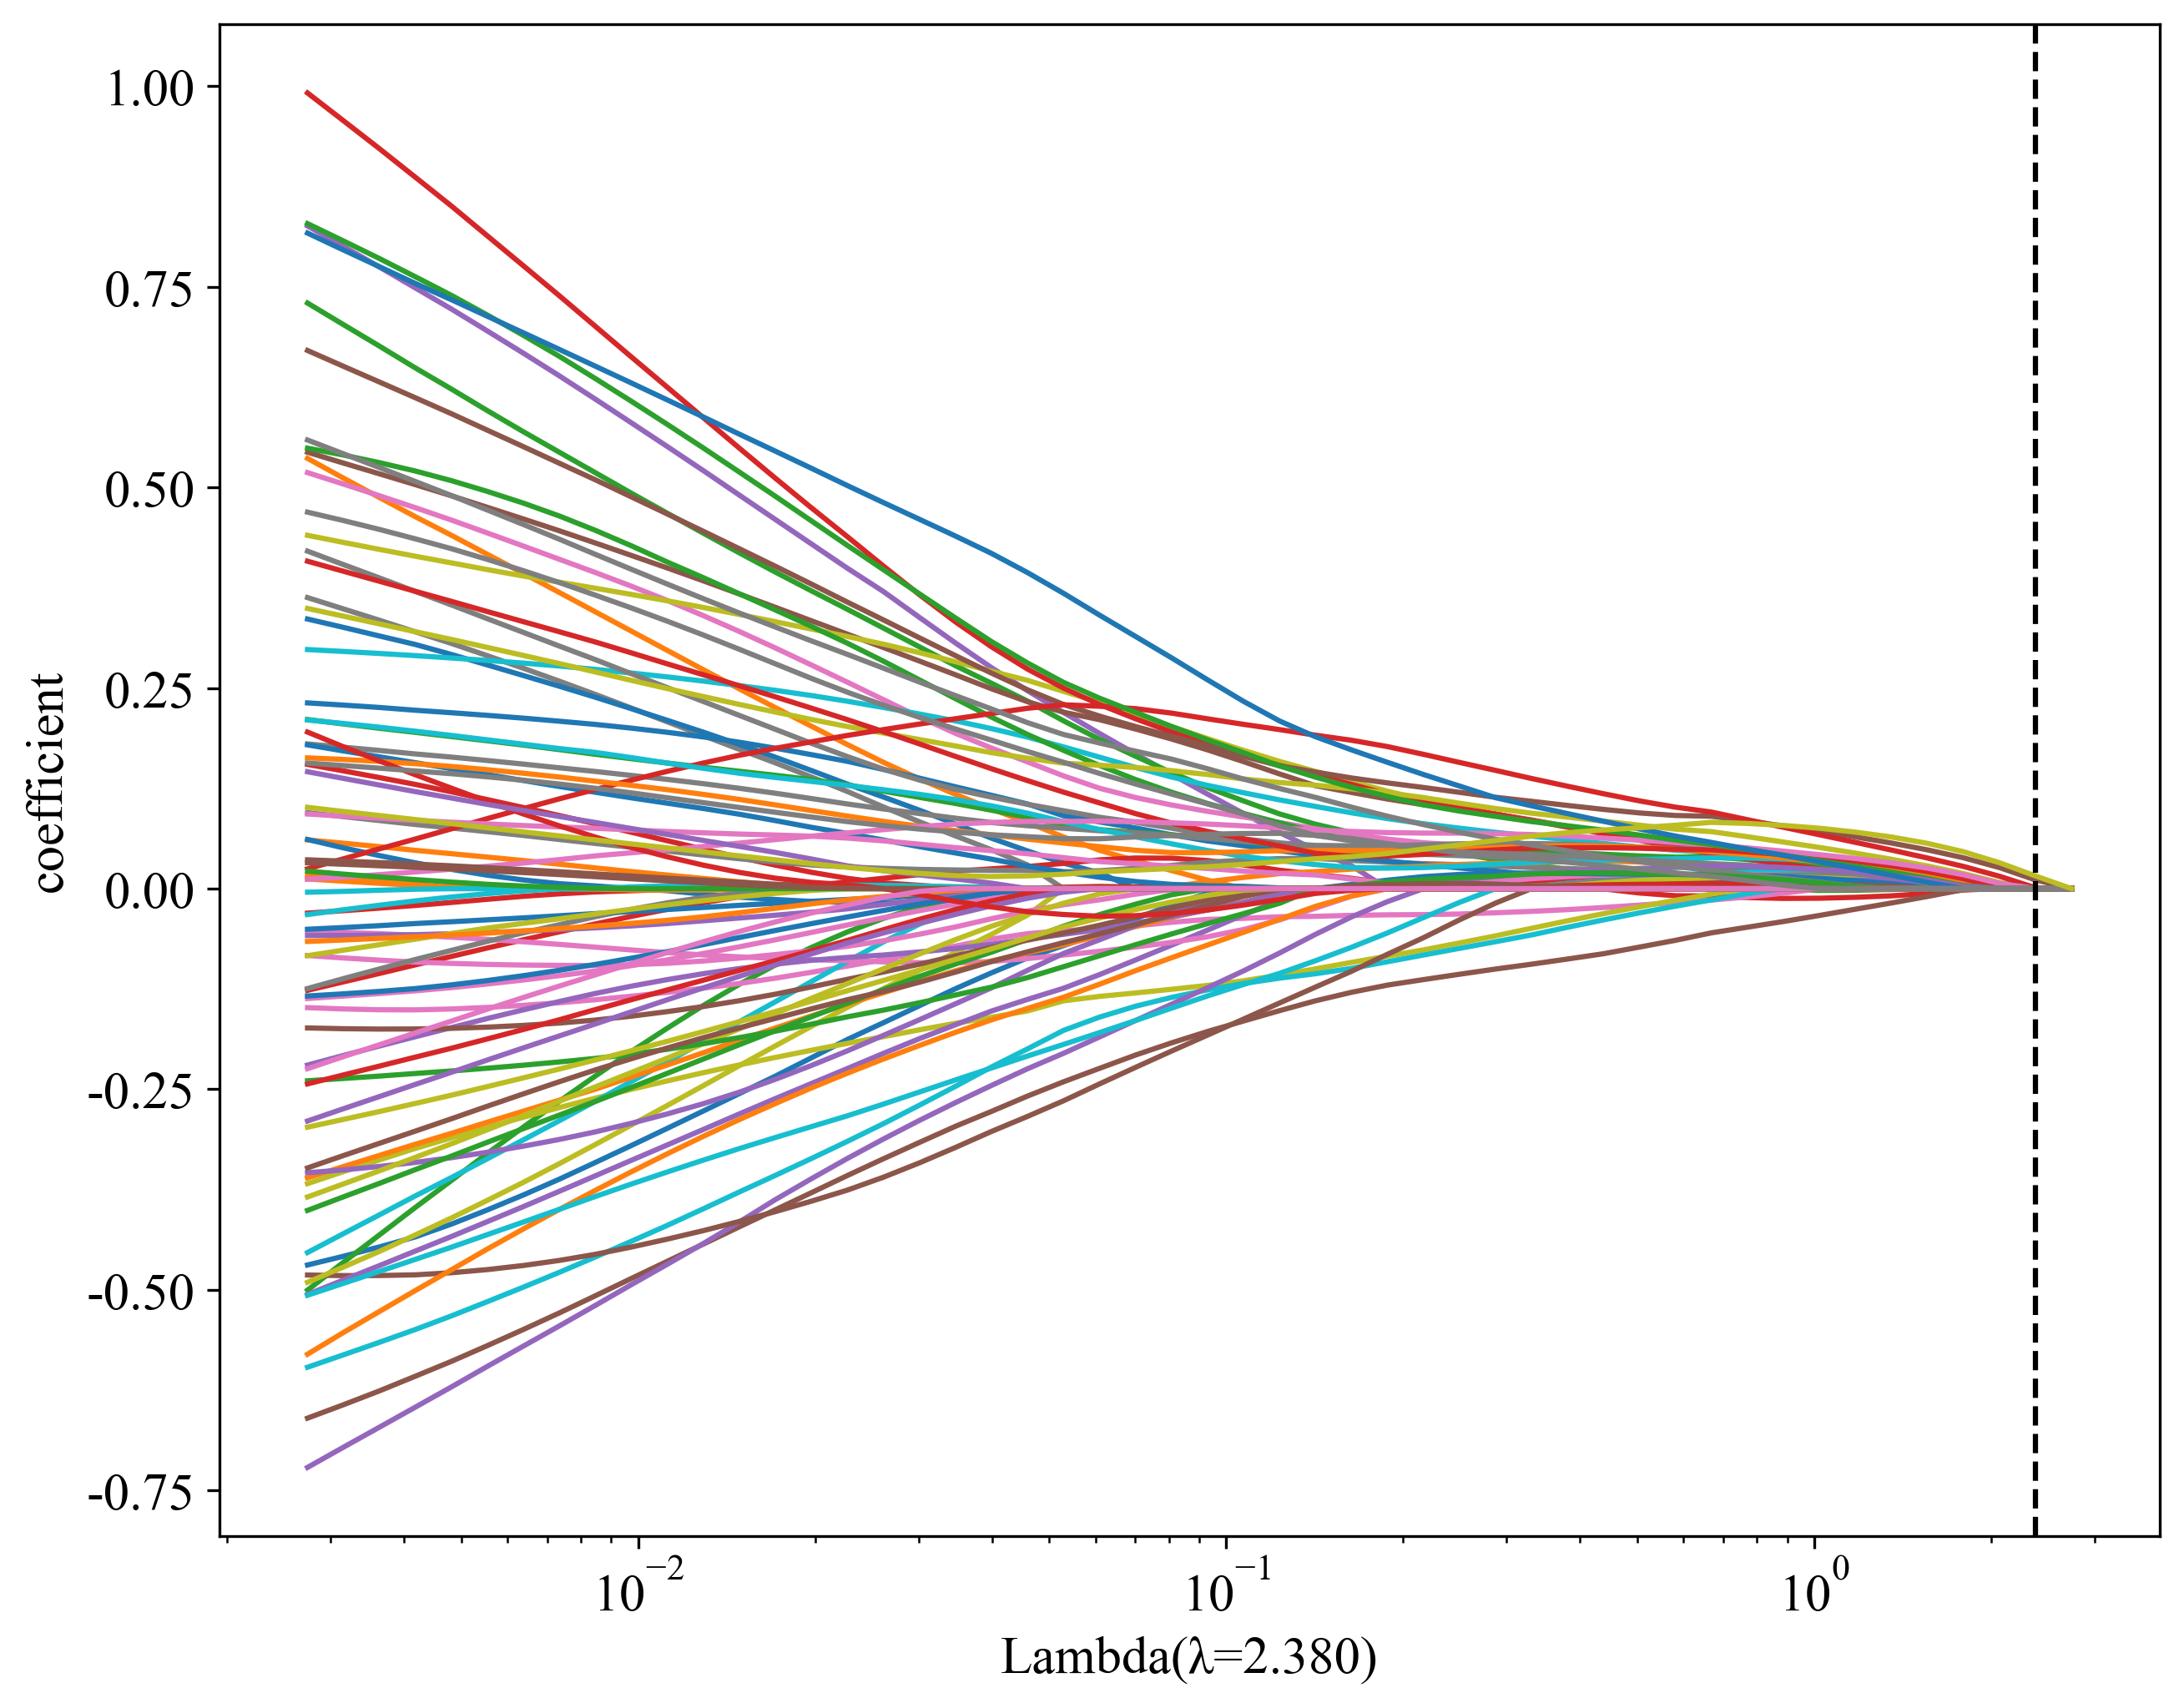

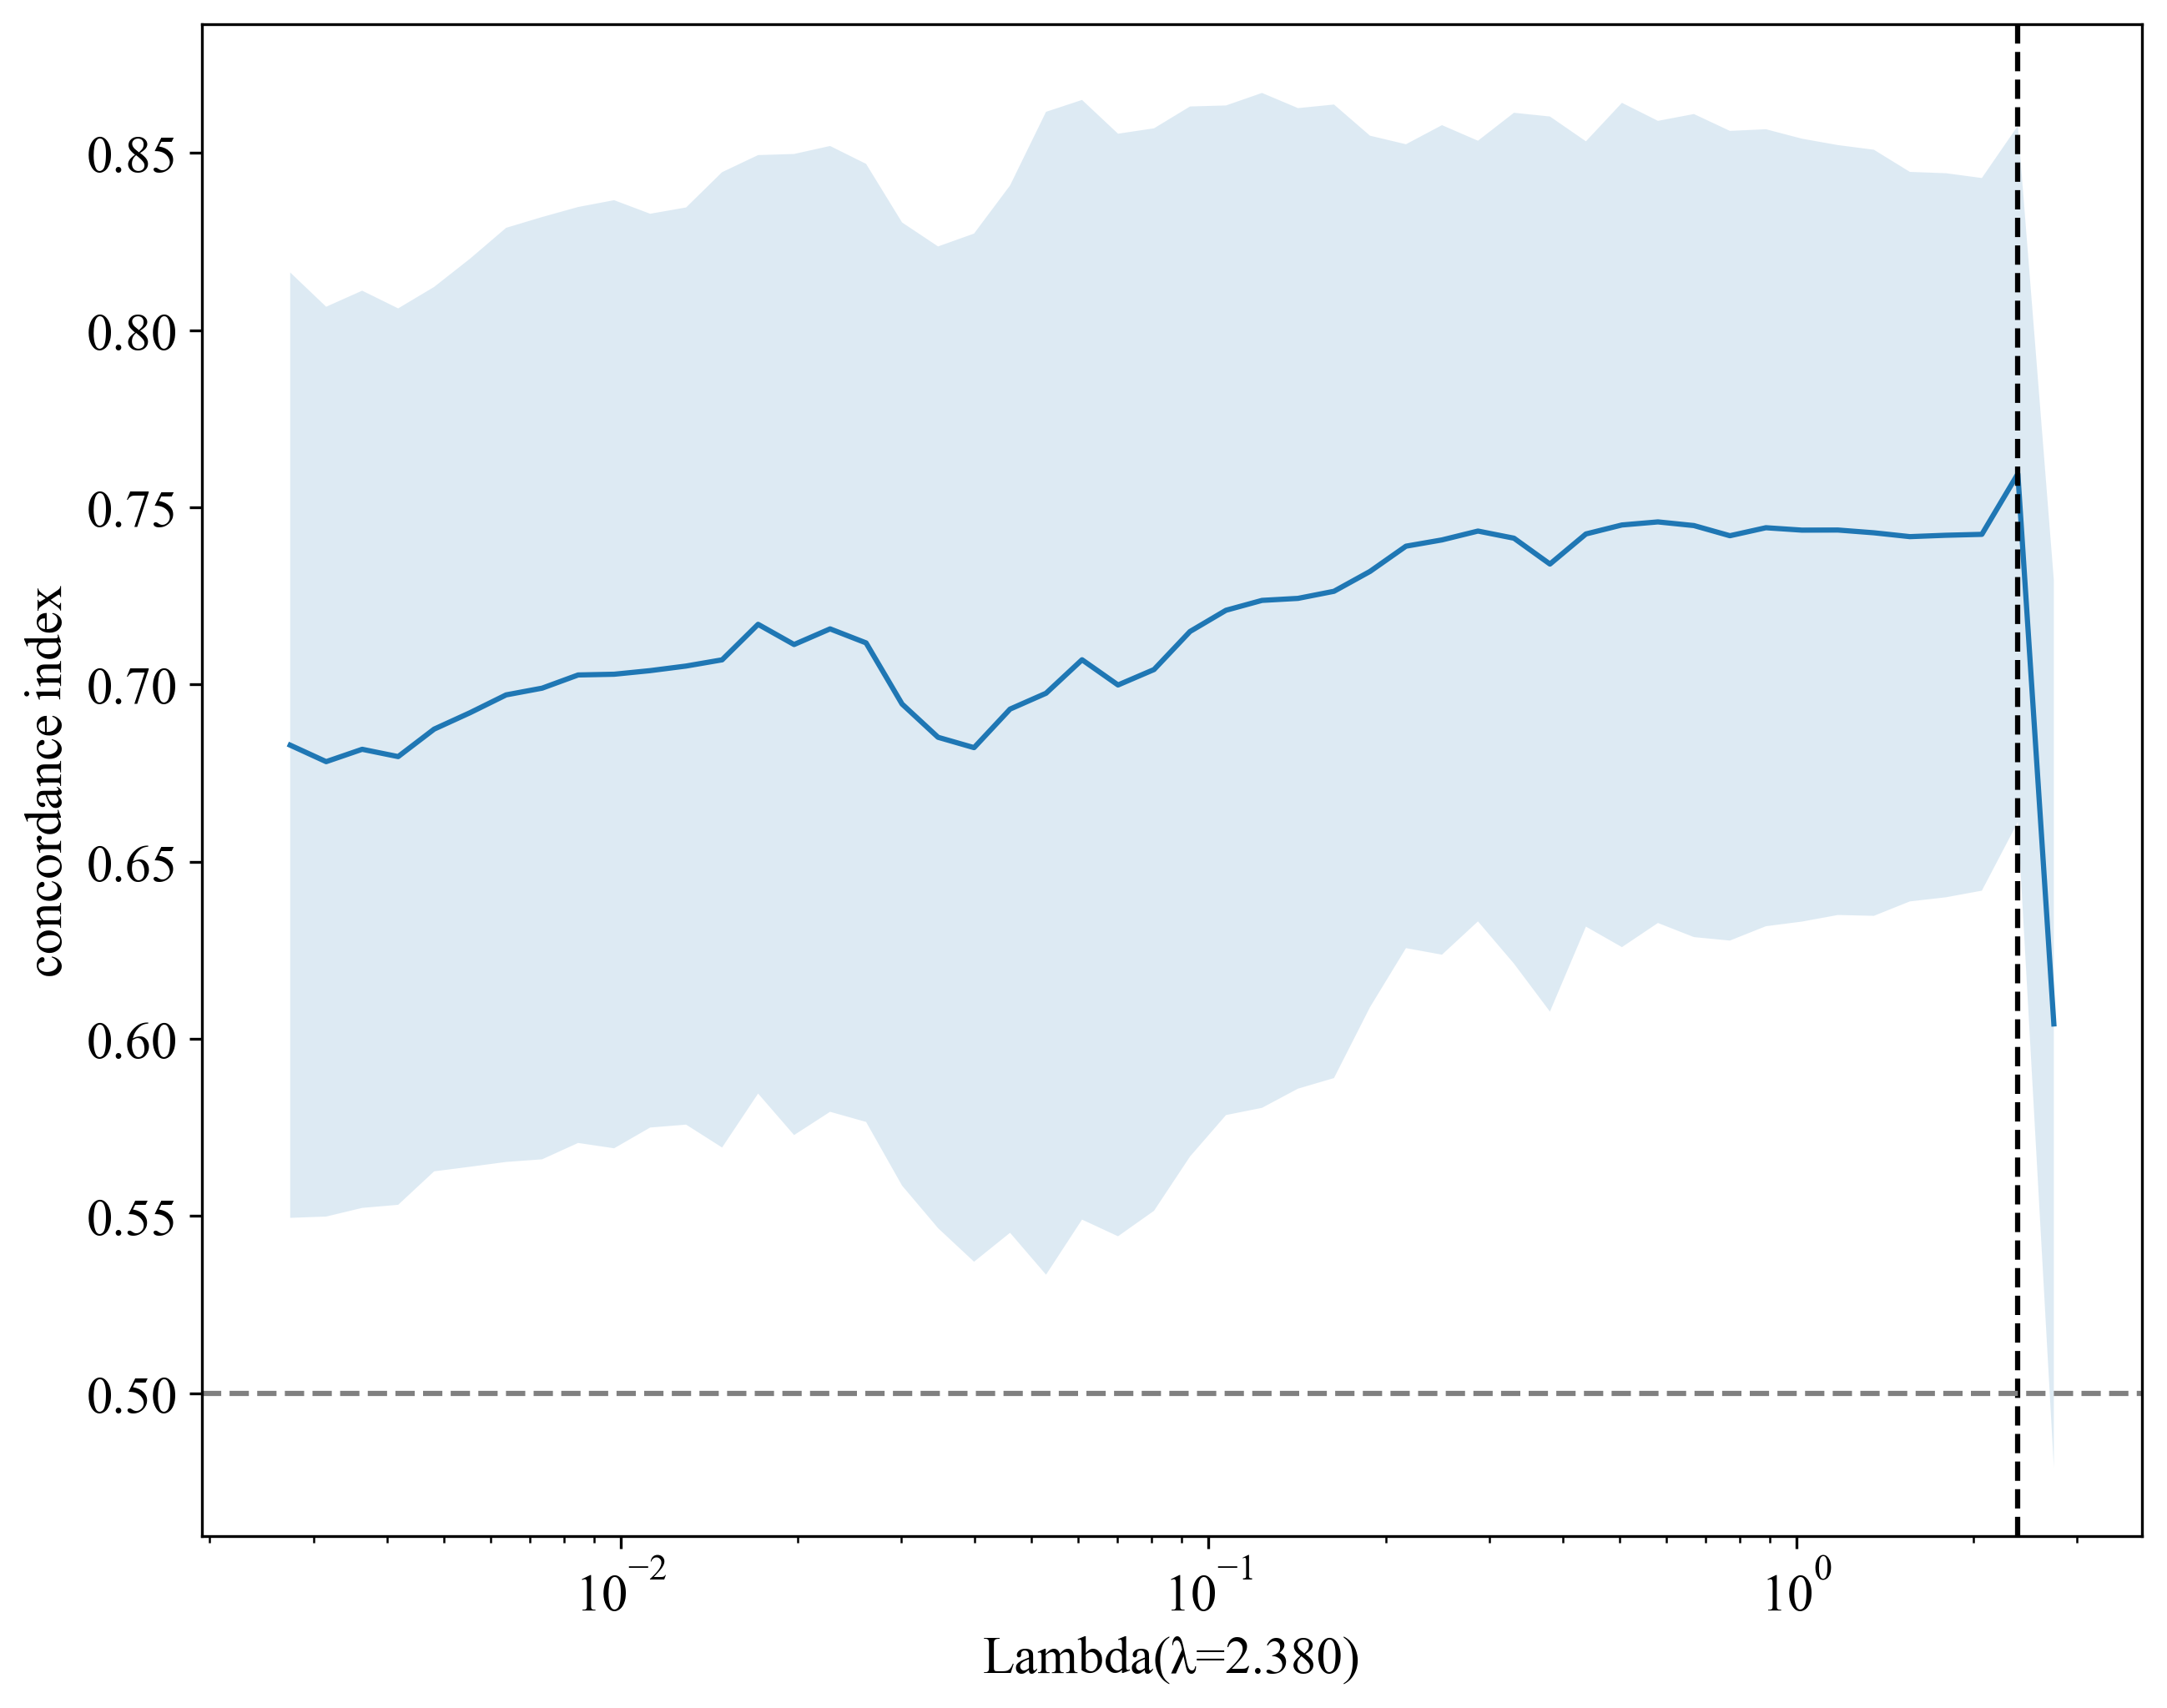

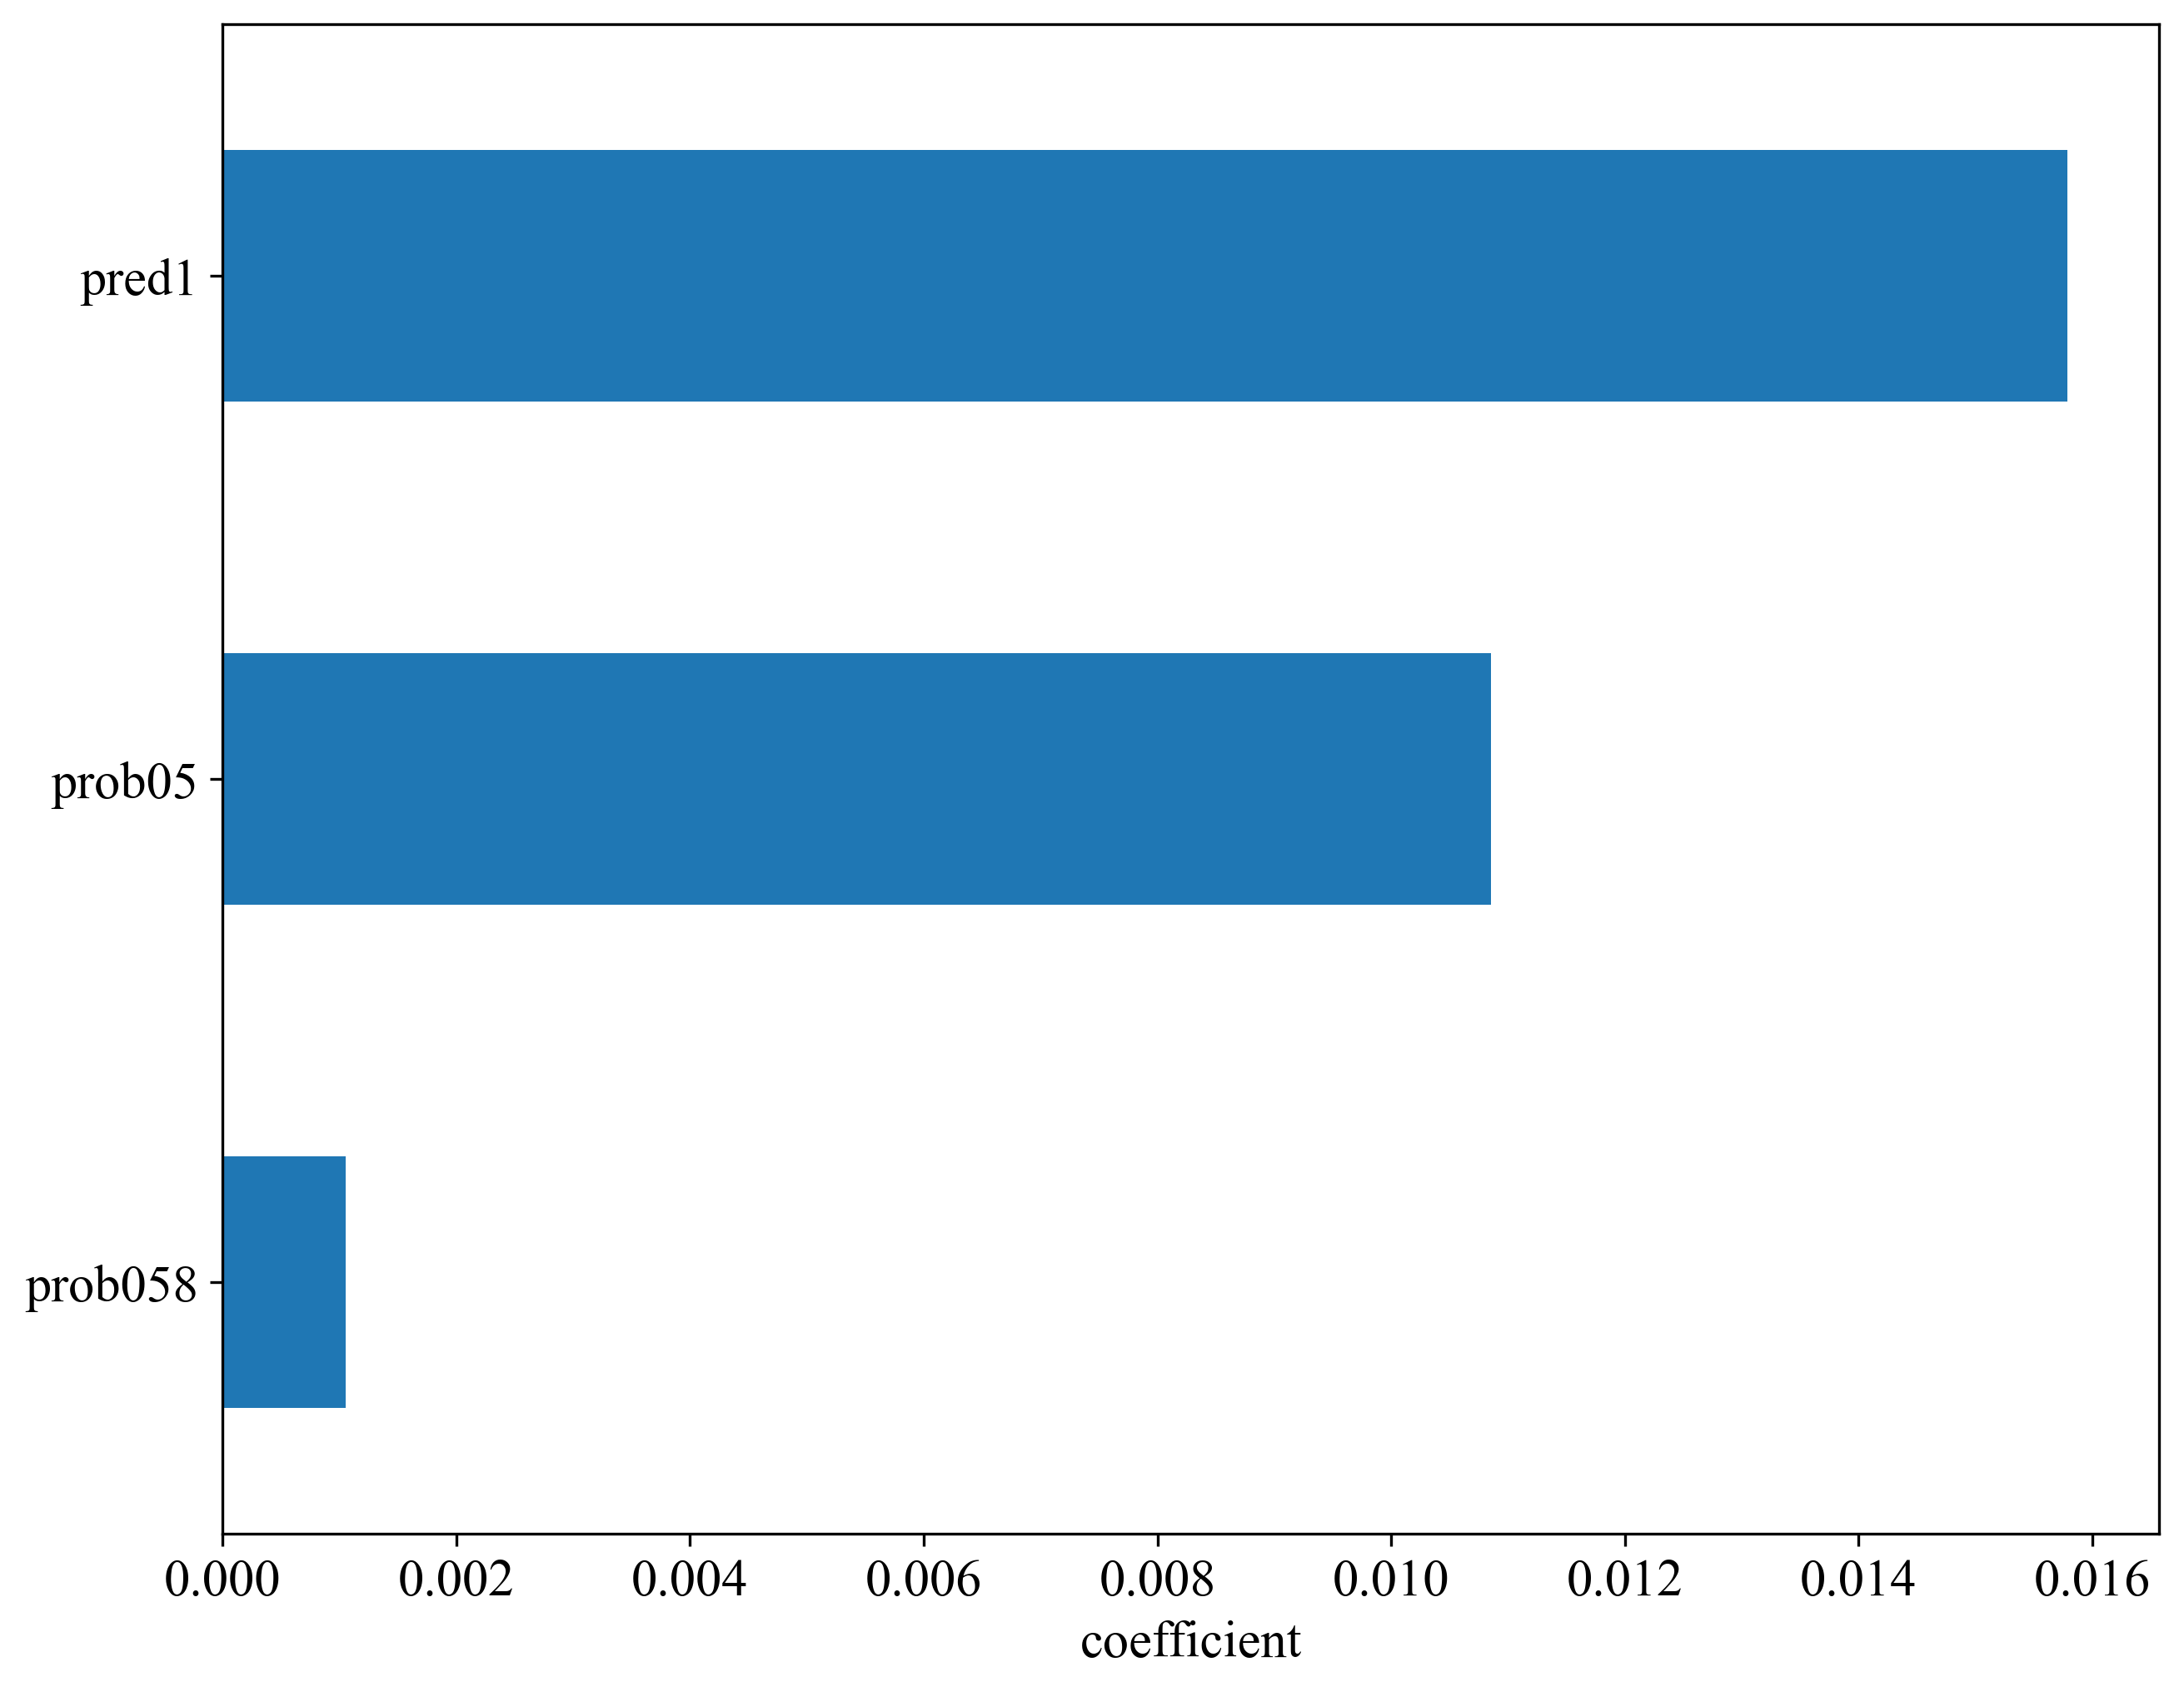

Survive = +0.001051 * prob058 +0.010858 * prob05 +0.015786 * pred1


In [9]:
from onekey_algo.custom.components.survival import get_x_y_survival, lasso_cox_cv
COEF_THRESHOLD = 1e-6

X, y = get_x_y_survival(train_data, val_outcome=1, event_col=event_col, duration_col=duration_col)
sel_features = lasso_cox_cv(X, y, max_iter=100,  norm_X=False, prefix=f"{task_type}", l1_ratio=0.1, cv=10, points=50)
# sel_features = lasso_cox_cv(X, y, max_iter=1000,  norm_X=False, prefix=f"{task}_", l1_ratio=0.8, cv=10)

In [10]:
train_data = train_data[['ID'] + list(sel_features.index) + [event_col, duration_col]]
for subset in subsets:
    val_datasets[subset] = val_datasets[subset][['ID'] + list(sel_features.index) + [event_col, duration_col]]
    val_datasets[subset].to_csv(f'features/{task_type}{subset}_cox.csv', index=False)

### 聚类分析

通过修改变量名，可以可视化不同相关系数下的相聚类分析矩阵。

注意：当特征特别多的时候（大于100），尽量不要可视化，否则运行时间会特别长。

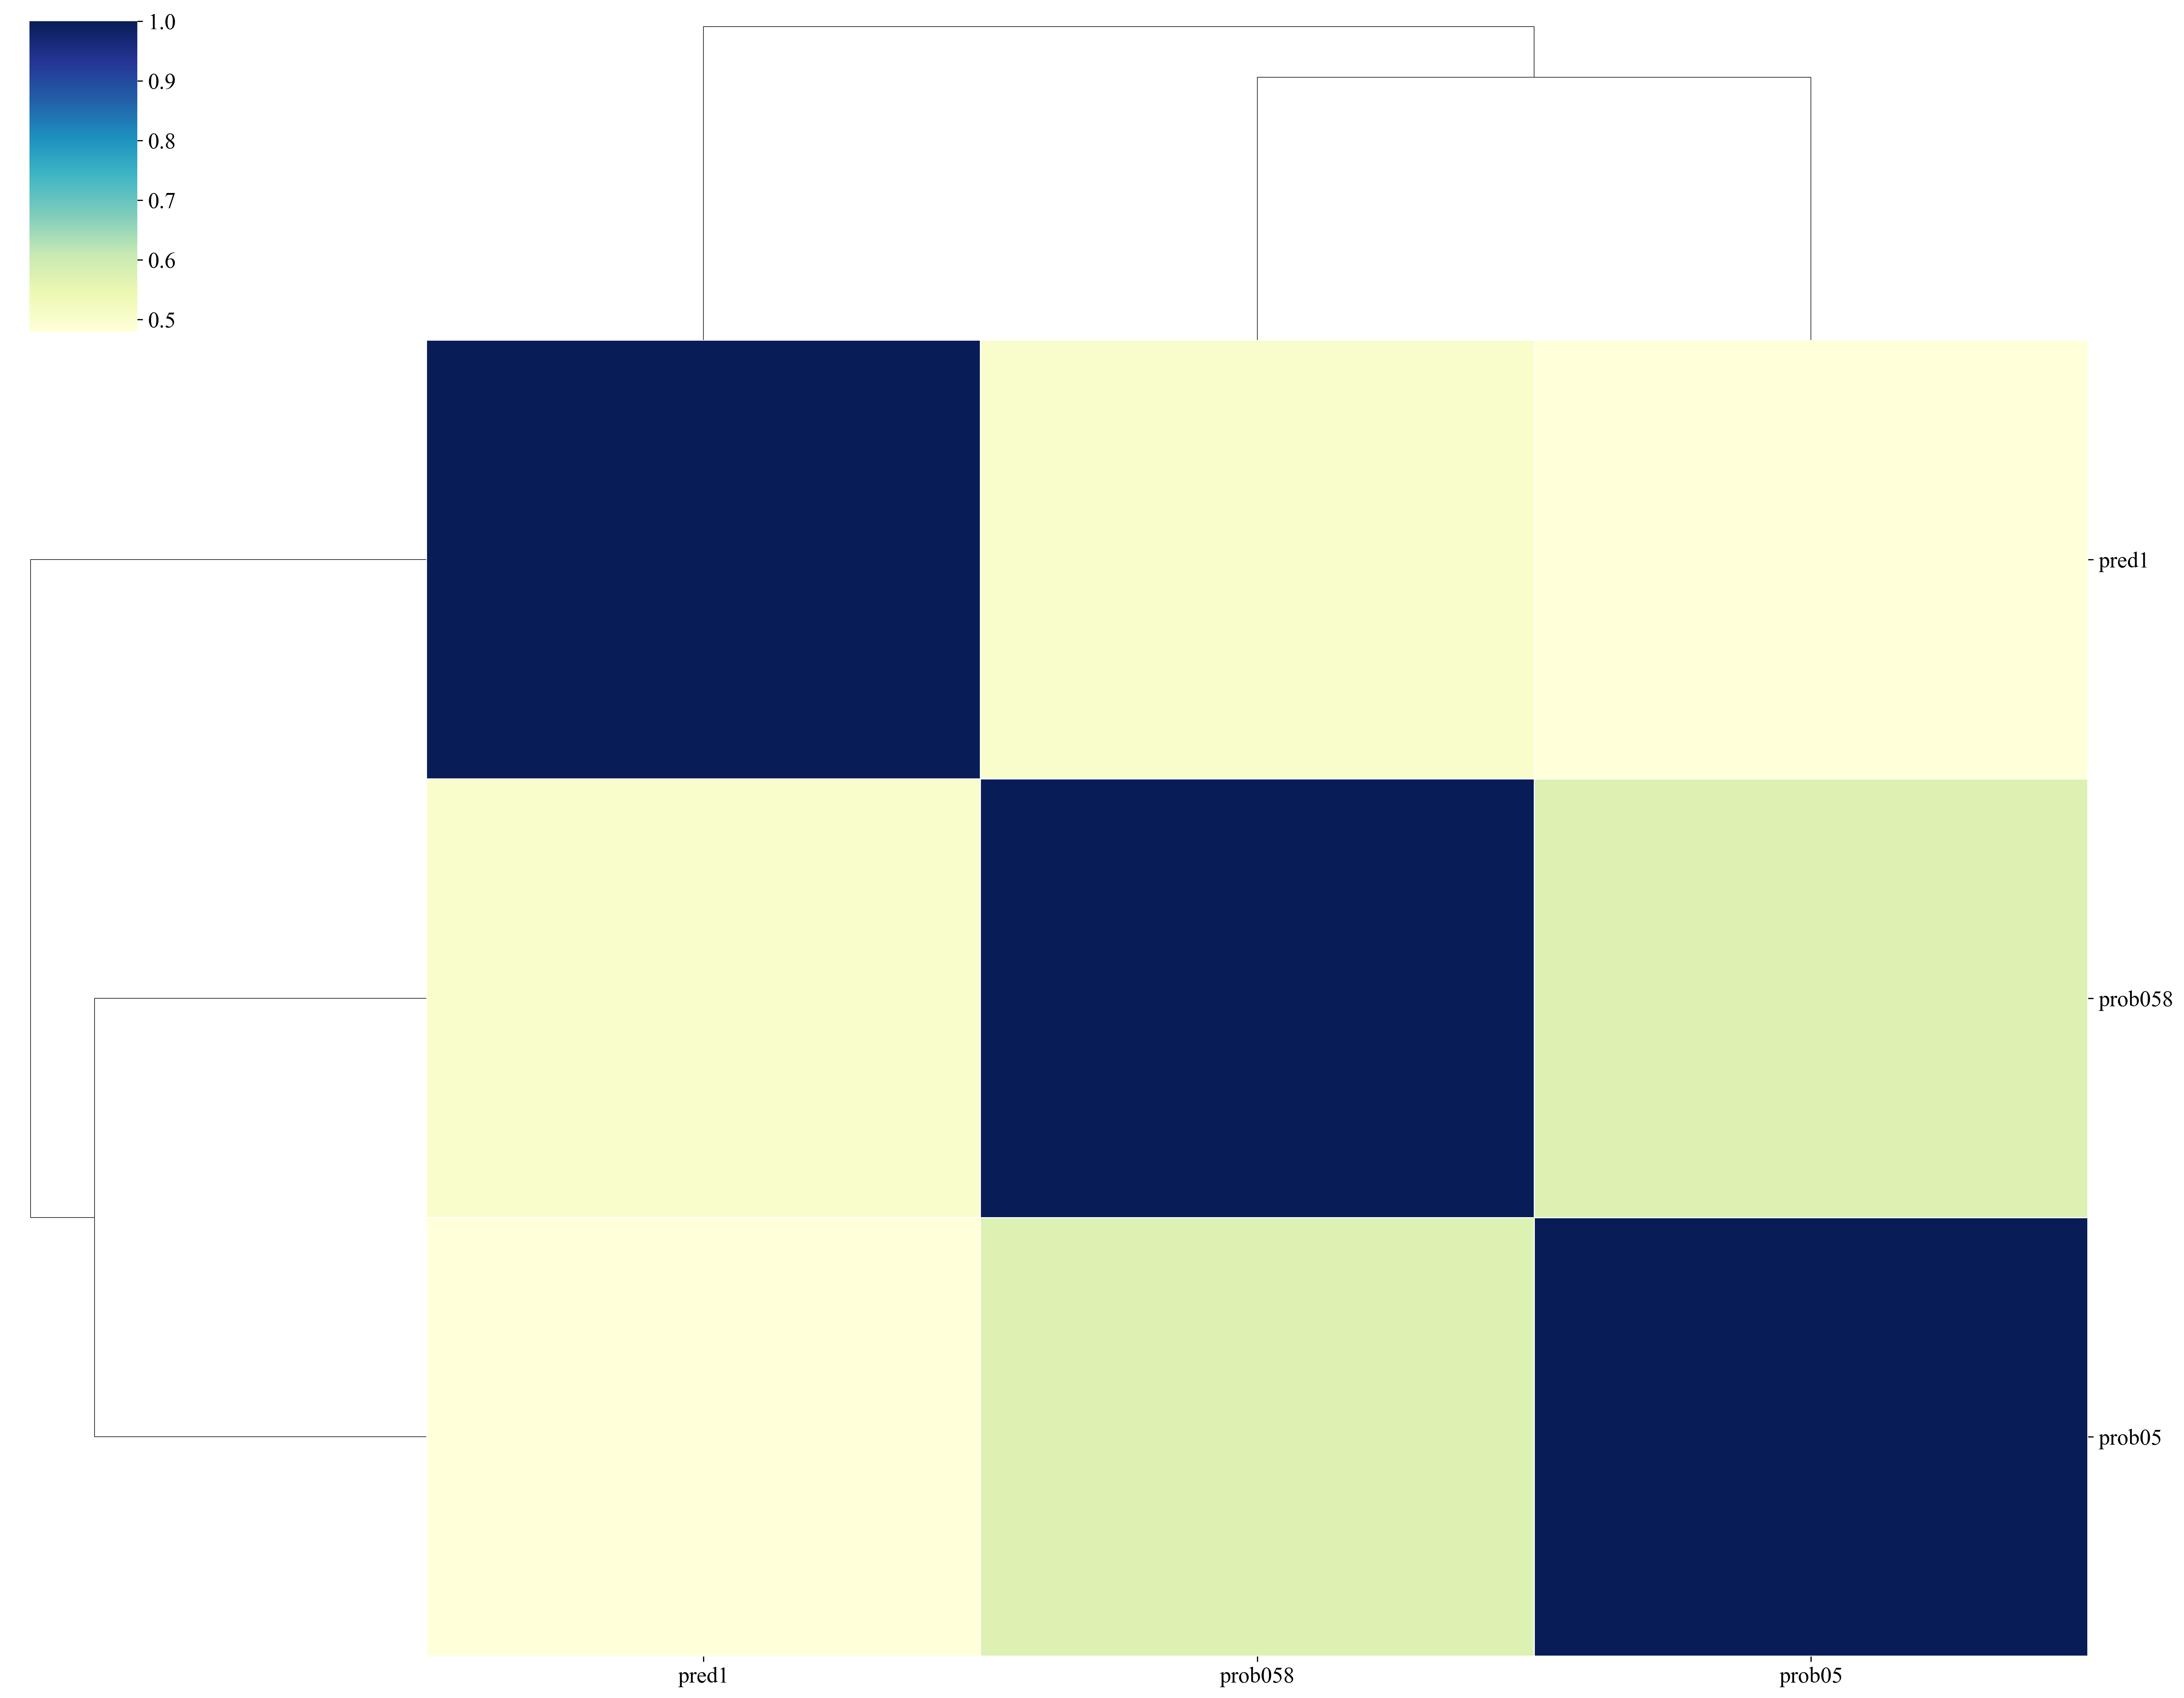

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

if train_data.shape[1] < 150:
    pp = sns.clustermap(train_data[[c for c in train_data.columns if c not in [event_col, duration_col, 'group']]].corr(corr_name), 
                        linewidths=.5, figsize=(20.0, 16.0), cmap='YlGnBu')
    plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)
    plt.savefig(f'img/{task_type}feature_cluster.svg', bbox_inches = 'tight')

In [12]:
from lifelines import CoxPHFitter
mci = 0
mp = None
for p in range(100):
    cph = CoxPHFitter(penalizer=p/100)
    cph.fit(train_data[[c for c in train_data.columns if c != 'ID']], duration_col=duration_col, event_col=event_col)
    test_data = val_datasets['test']
    ci = cph.score(test_data[[c for c in test_data.columns if c != 'ID']], scoring_method="concordance_index")
    if mci < ci:
        print(p, ci)
        mci = ci
        mp = p / 100

0 0.7645466847090663
1 0.7658998646820027
5 0.7672530446549392
8 0.7686062246278755


In [13]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.00)
cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 139 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 55
   partial log-likelihood = -234.32
         time fit was run = 2025-09-12 14:28:11 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
prob058     0.32       1.38       0.11             0.11             0.53                 1.12                 1.70
prob05      0.52       1.68       0.12             0.29             0.74                 1.34                 2.11
pred1       0.59       1.81       0.10             0.39             0.80                 1.47                 2.22

            cmp to    z      p   -log2(p)
covariate                                
prob058       0.00 3.04 <0.005       8.74
prob05        0.00 4.45 <0.005      16.85
pred1         0.00 5.64 <0.005      25.79
---
Concordance = 0.77
Partial AIC = 474.64
log-likelihood ratio test = 86.66 on 3 df
-log2(p) of ll-ratio test = 59.61

In [14]:
print(cph.concordance_index_)
su = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
su.columns = ['HR', 'HR lower 95%', 'HR upper 95%', 'pvalue']
su.reset_index().to_csv(f'features/{task_type}_features_HR.csv', index=False)
su

0.7669706180344478


,HR,HR lower 95%,HR upper 95%,pvalue
covariate,,,,
prob058,1.379,1.121,1.696,2.333e-03
prob05,1.677,1.336,2.106,8.473e-06
pred1,1.806,1.471,2.218,1.720e-08


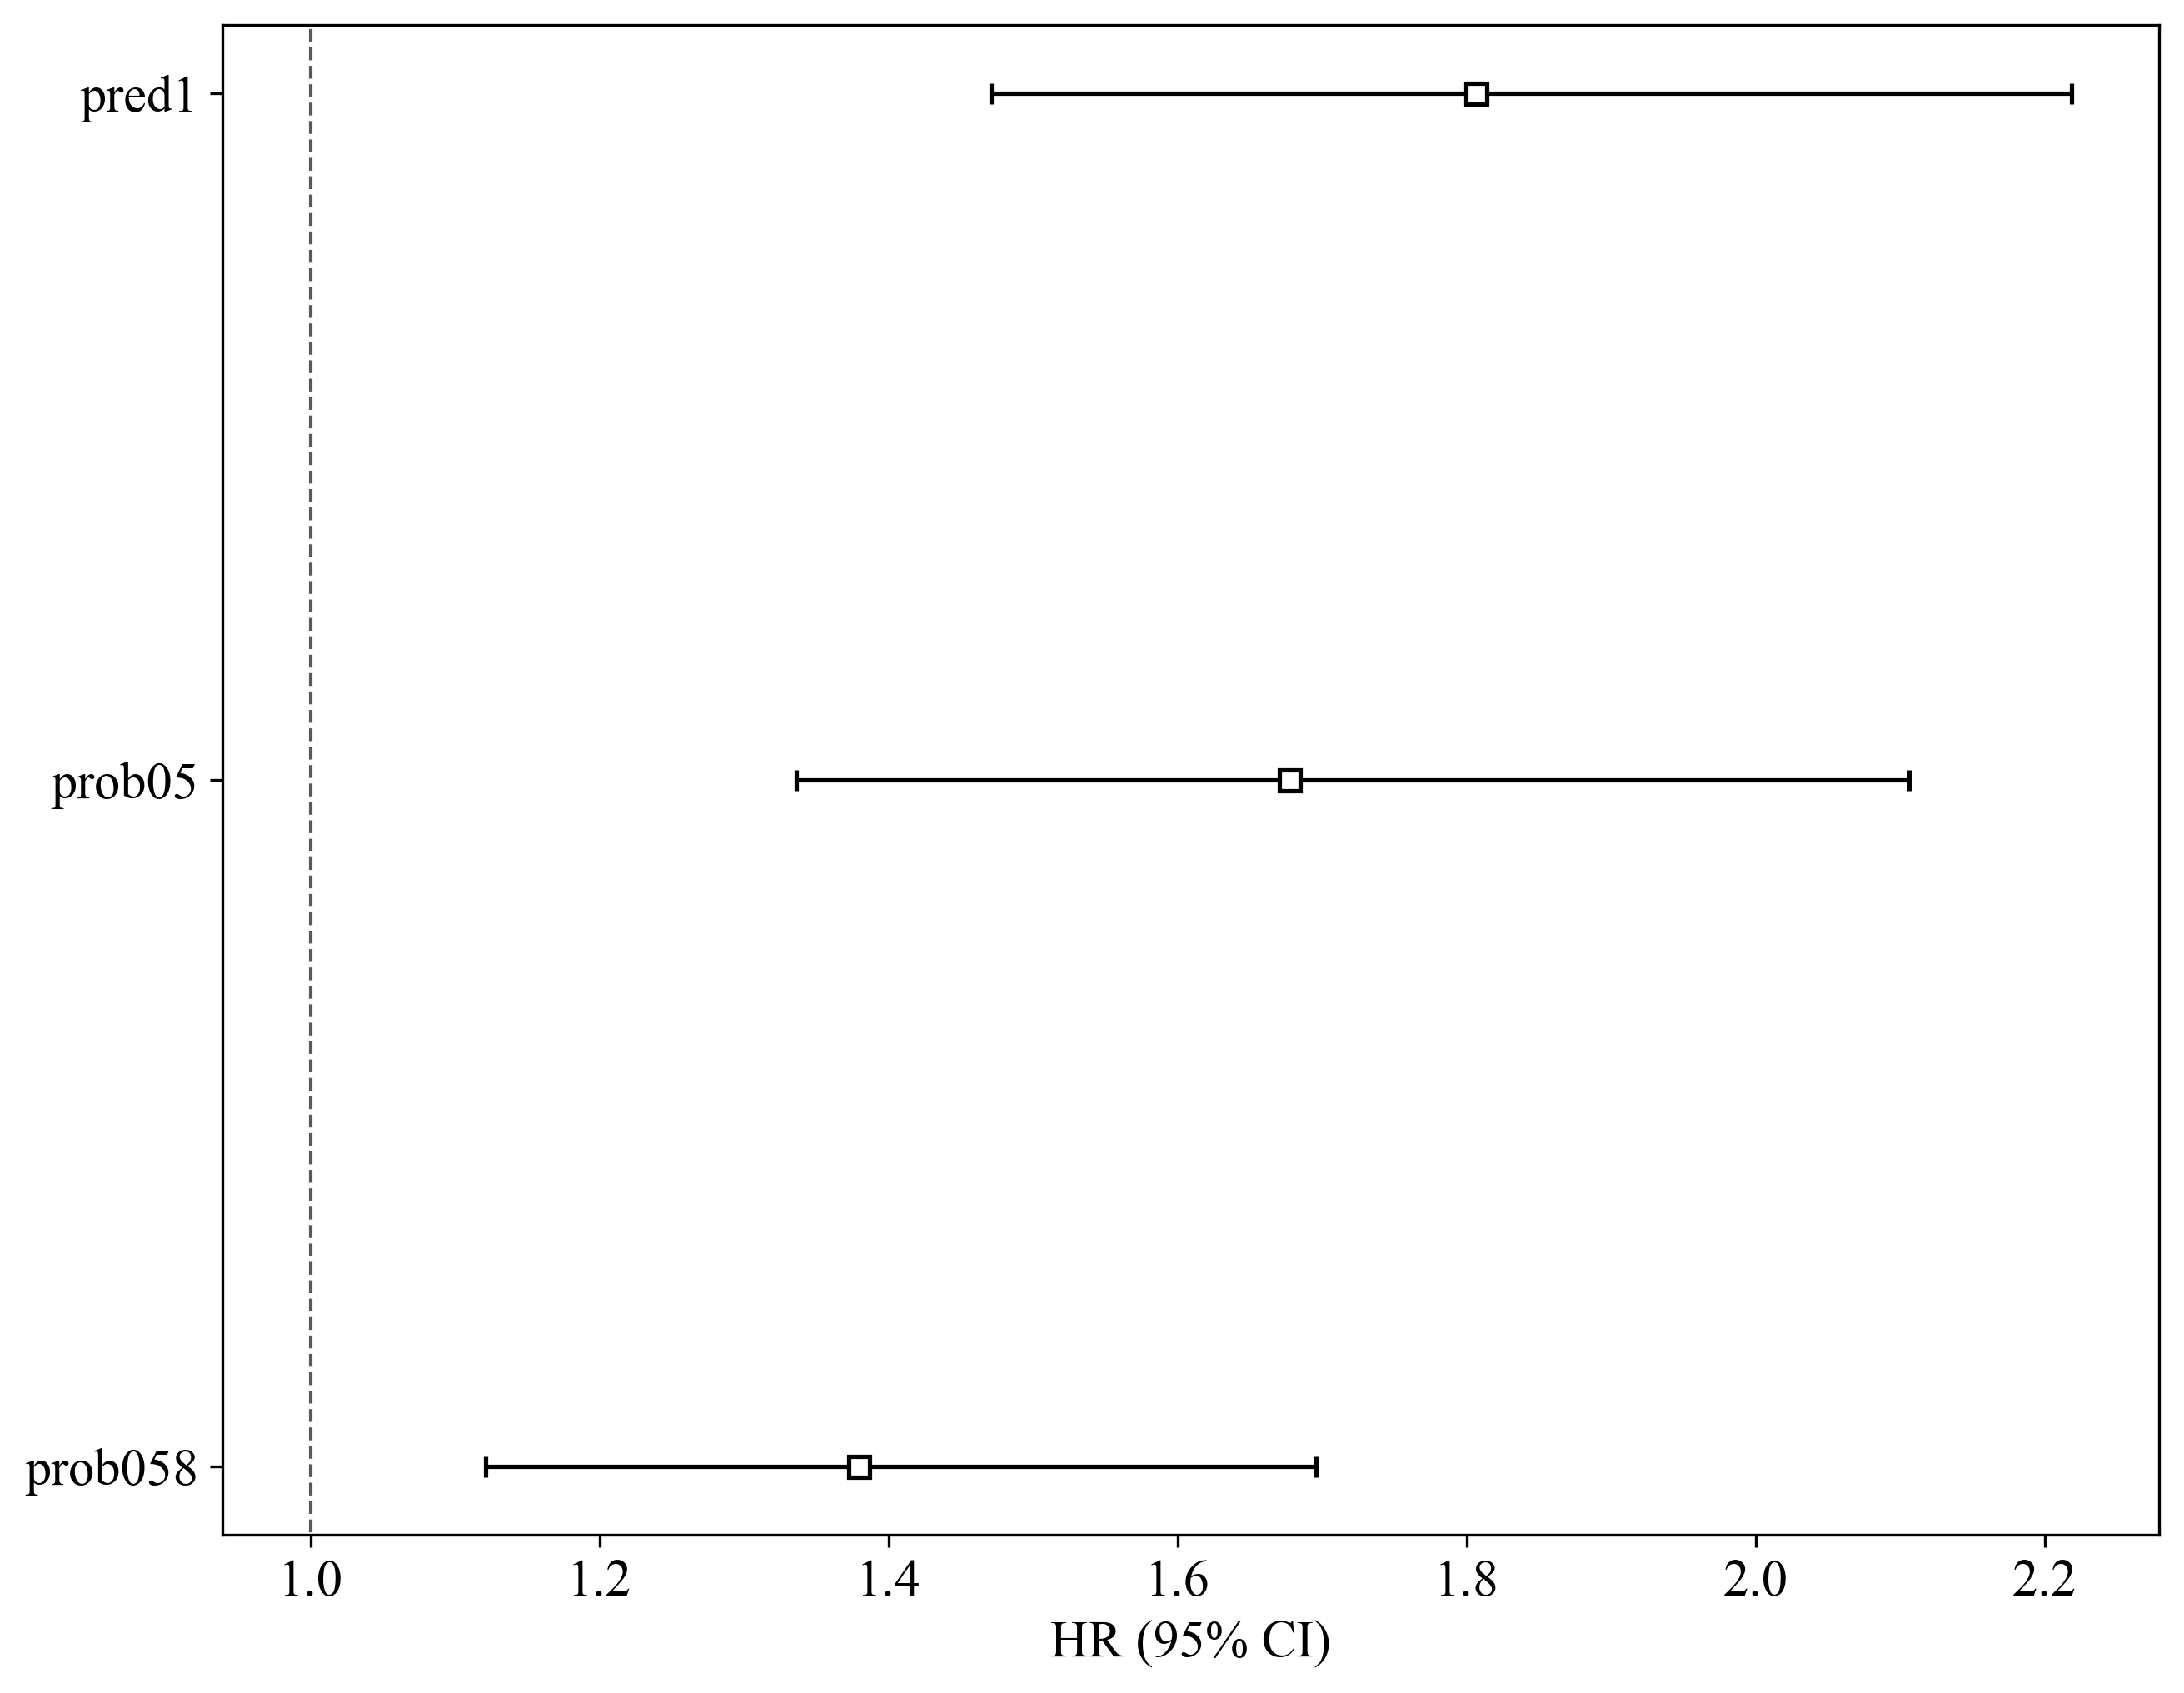

In [15]:
import matplotlib.pyplot as plt

cph.plot(hazard_ratios=True)
plt.savefig(f'img/{task_type}feature_pvalue.svg')
plt.show()

In [16]:
from onekey_algo.custom.components.ugly import drop_survival

# del_num = {'test': 0,}
# for subset in ['test']:
#     val_data = val_datasets[subset]
#     cox_data = val_data[[c for c in val_data.columns if c not in ['group']]]
#     kid = drop_survival(cox_data, cph, drop_num=del_num[subset], is_drop_ids=False)
#     display(kid)
#     val_data = pd.merge(val_data, kid[['ID']], on='ID', how='inner')
# #     val_datasets[subset] = val_data
#     val_datasets[subset+'_sel'] = val_data
print('，'.join([f"{subset}样本数：{d_.shape[0]}" for subset, d_ in val_datasets.items()]))

train样本数：194，test样本数：84


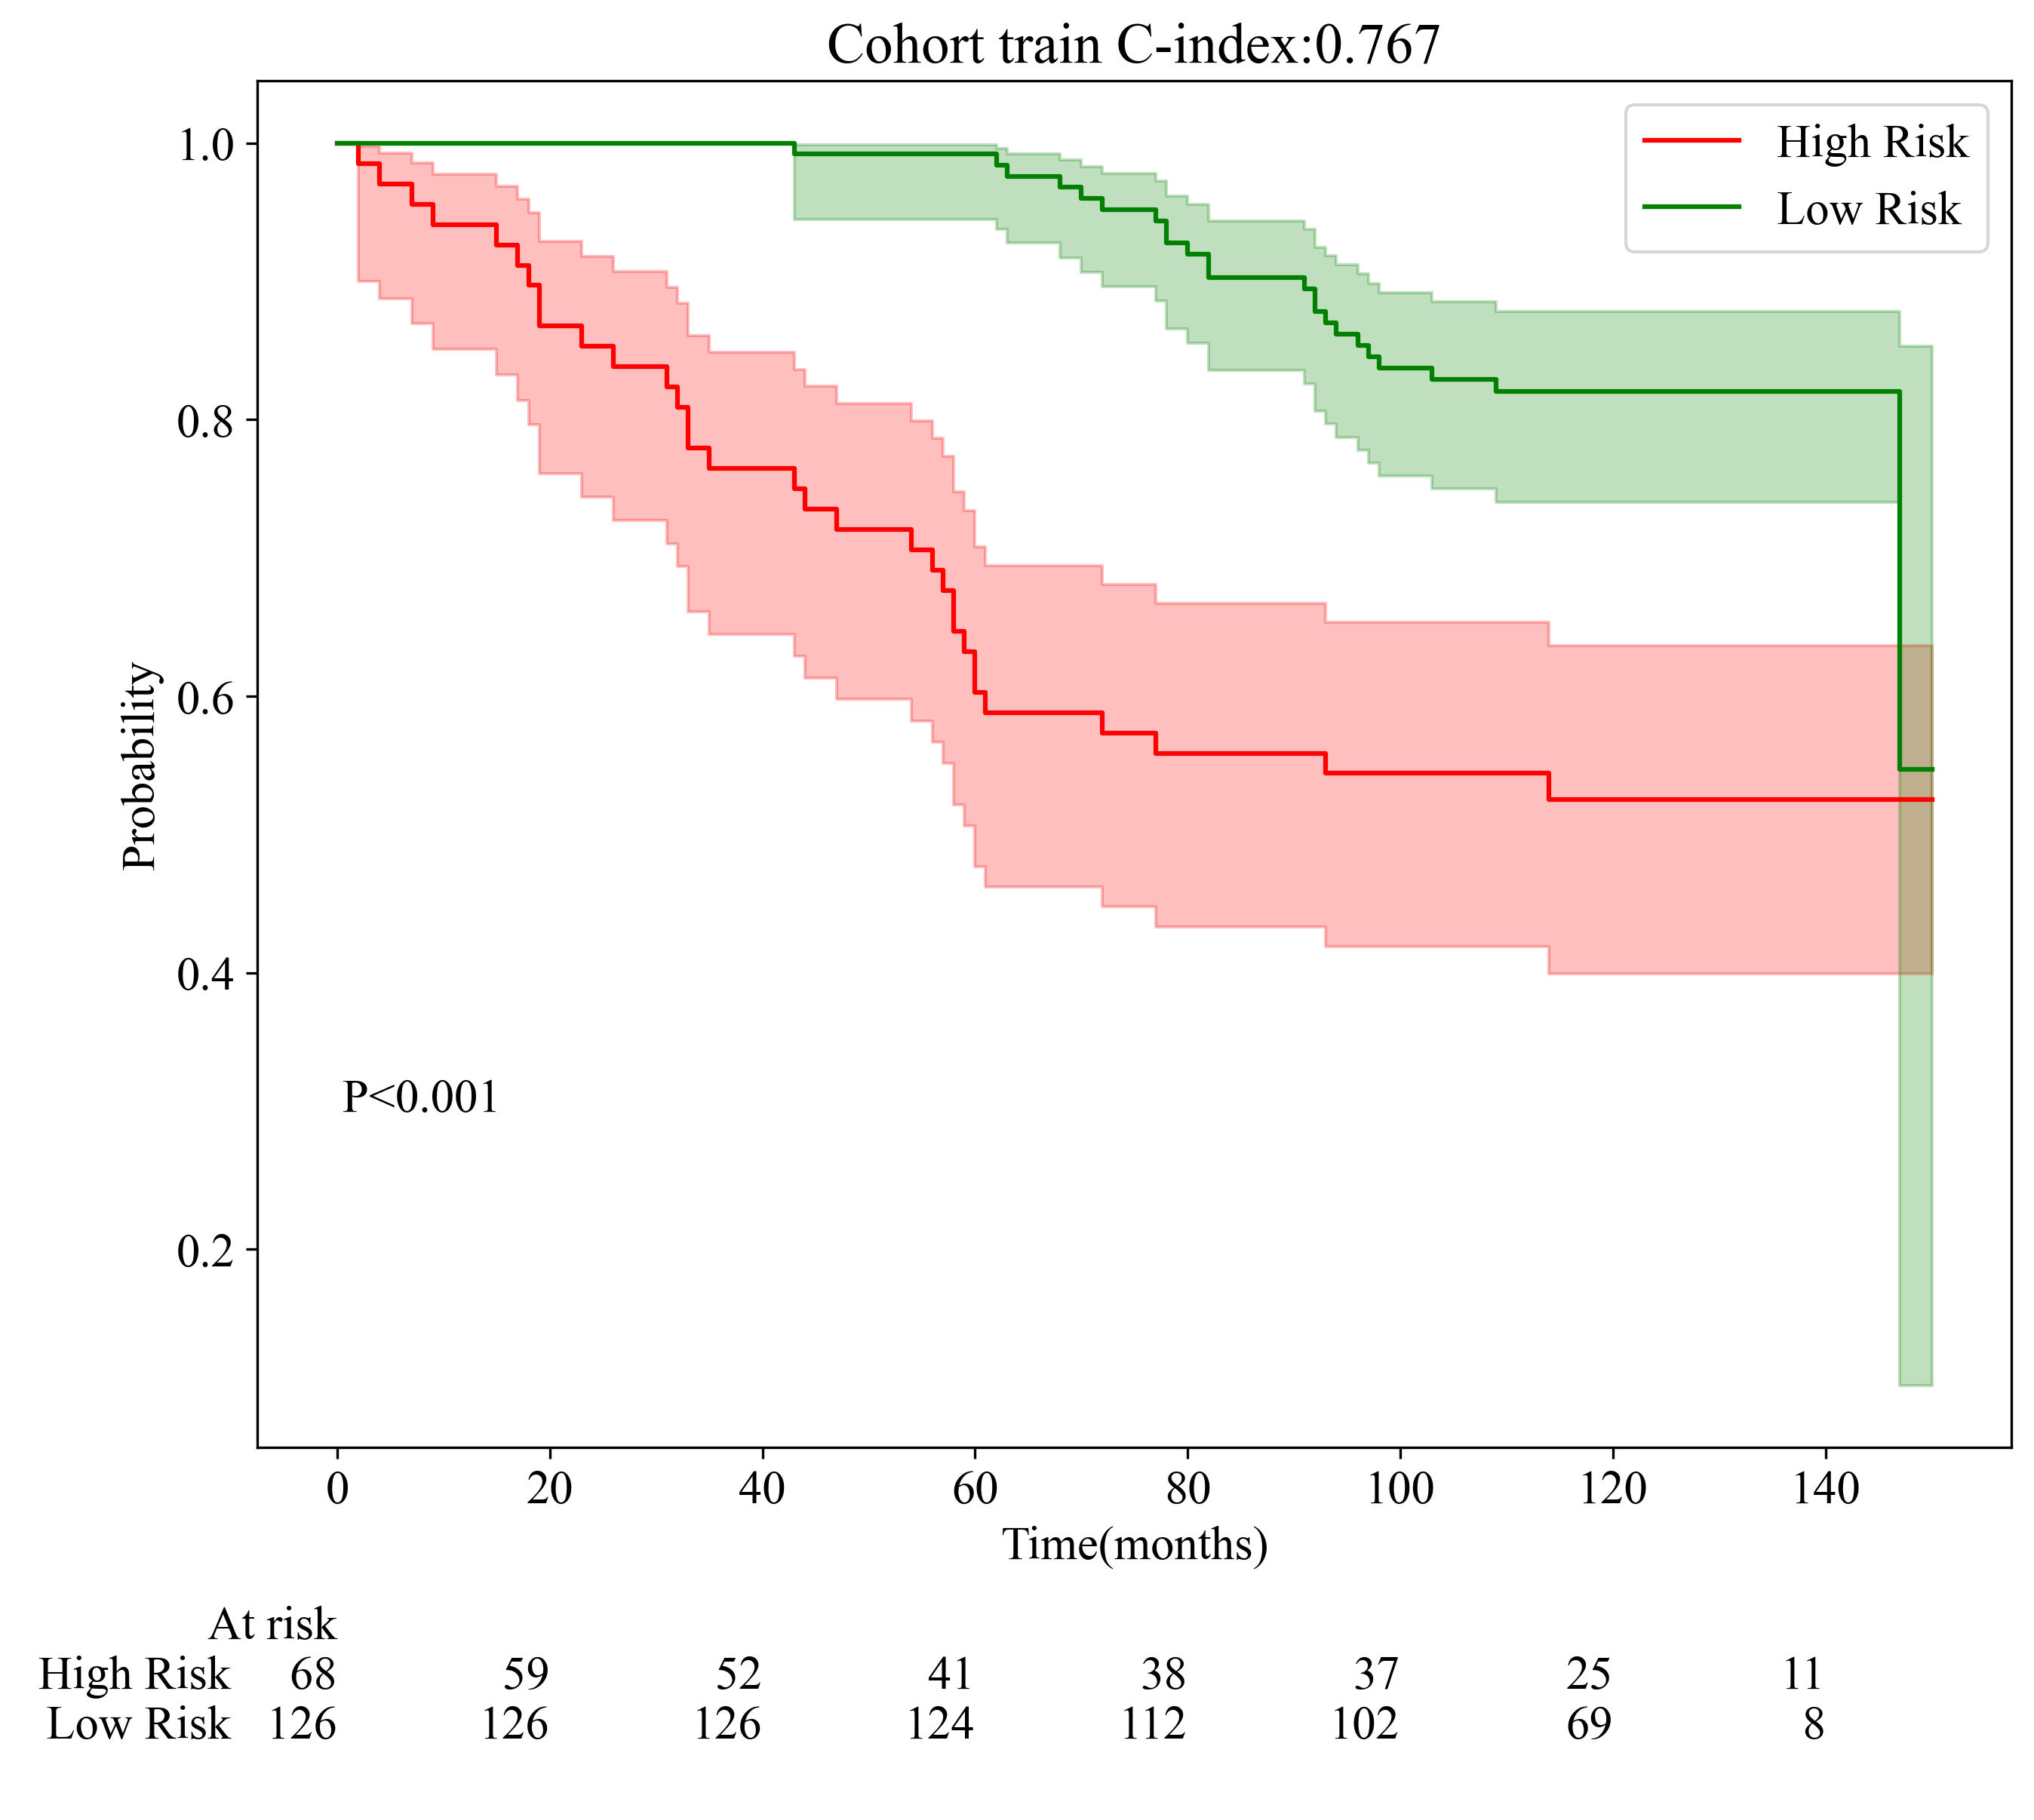

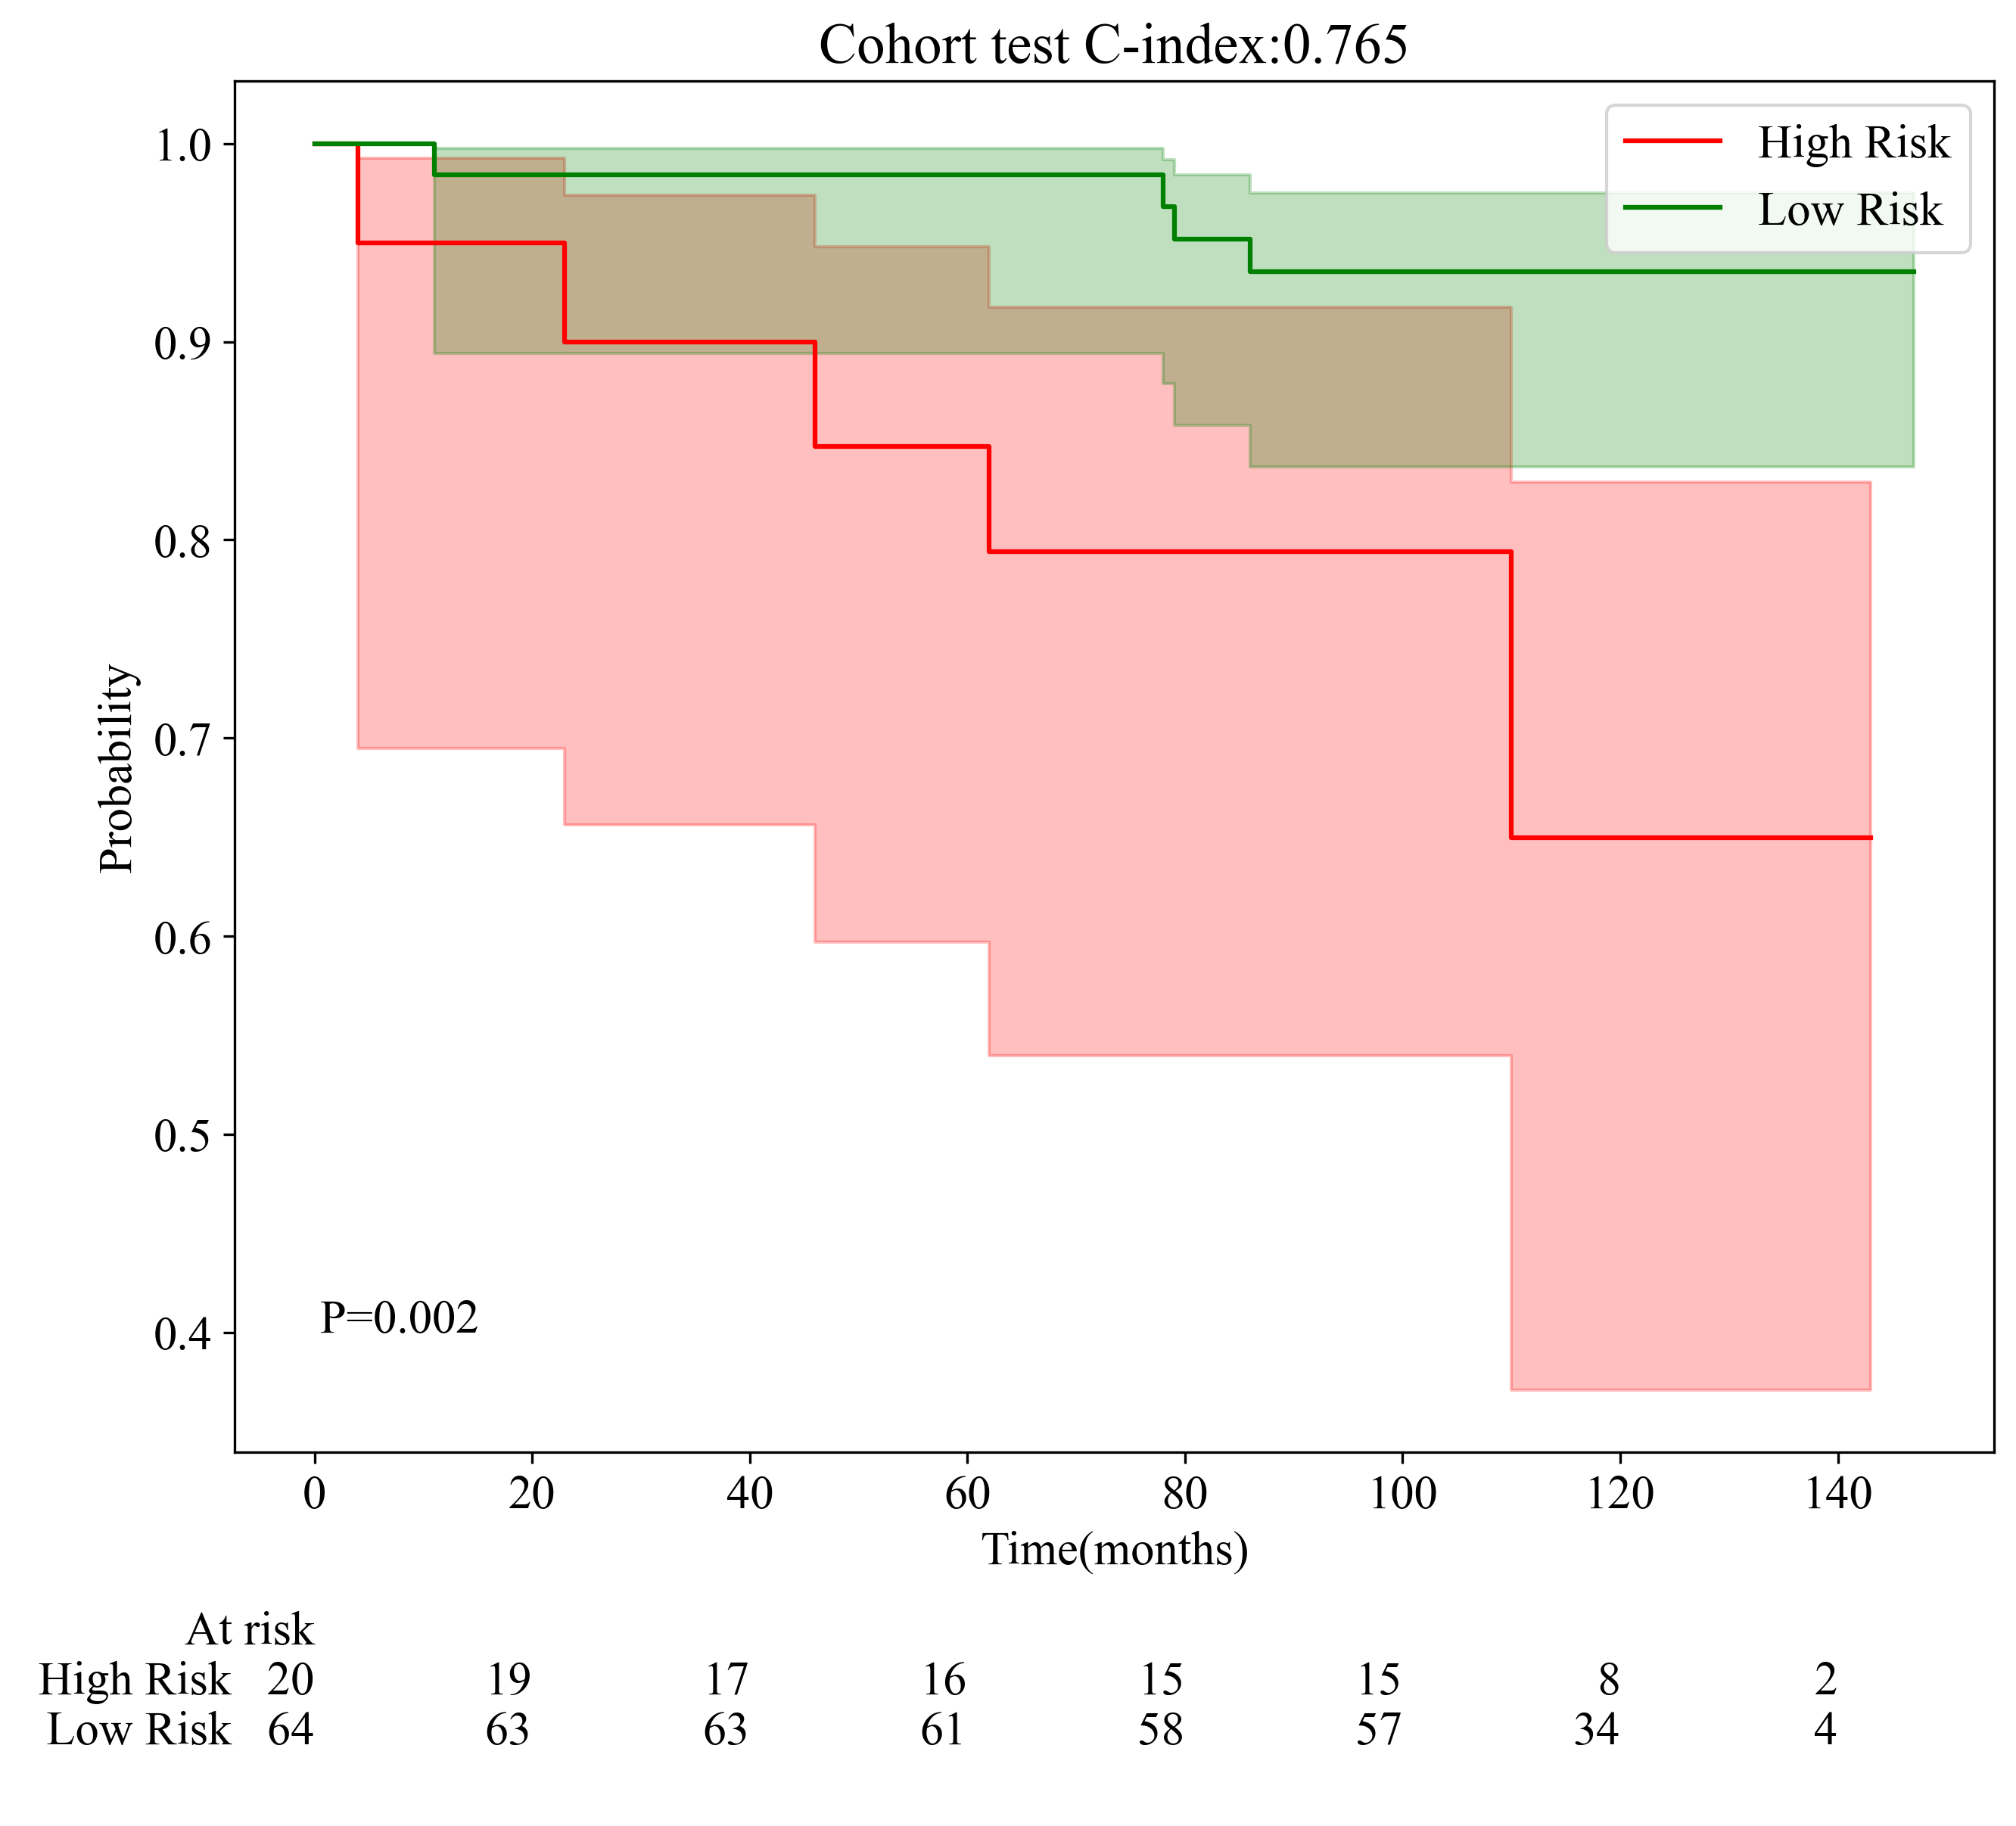

In [17]:
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

thres = 0.001
bst_split = {'train': 0.8, 'test':0.8, 'val': 1, 'test_sel':1.4, 'val_sel': 1}
loc = {'train': 0.3, 'val':0.2, 'test': 0.4, 'KH':0.2, 'CY':0.4}
for subset, test_data in val_datasets.items():
    c_index = cph.score(test_data[[c for c in test_data.columns if c != 'ID']], scoring_method="concordance_index")
#     y_pred = cph.predict_median(test_data[[c for c in test_data.columns if c != 'ID']])
#     cox_data = pd.concat([test_data, y_pred], axis=1)
#     mean = cox_data.describe()[0.5]['mean']
#     cox_data['HR'] = cox_data[0.5] < mean
    y_pred = cph.predict_partial_hazard(test_data[[c for c in test_data.columns if c != 'ID']])
    cox_data = pd.concat([test_data, y_pred], axis=1)
    mean = cox_data.describe()[0]['50%']
    cox_data['HR'] = cox_data[0] >= bst_split[subset]
#     cox_data['HR'] = cox_data[0] > mean

    dem = (cox_data["HR"] == True)
    results = logrank_test(cox_data[duration_col][dem], cox_data[duration_col][~dem], 
                           event_observed_A=cox_data[event_col][dem], event_observed_B=cox_data[event_col][~dem])
    p_value = f"={results.p_value:.3f}" if results.p_value > thres else f'<{thres}'
    plt.title(f"Cohort {subset} C-index:{c_index:.3f}")
    plt.ylabel('Probability')
    if sum(dem):
        kmf_high = KaplanMeierFitter()
        kmf_high.fit(cox_data[duration_col][dem], event_observed=cox_data[event_col][dem], label="High Risk")
        kmf_high.plot_survival_function(color='r')
    if sum(~dem):
        kmf_low = KaplanMeierFitter()
        kmf_low.fit(cox_data[duration_col][~dem], event_observed=cox_data[event_col][~dem], label="Low Risk")
        kmf_low.plot_survival_function(color='g')
    plt.text(0.5, loc[subset] if subset in loc else 0.2, f"P{p_value}")
    plt.xlabel('Time(months)')
    add_at_risk_counts(kmf_high, kmf_low, rows_to_show=['At risk'])
    plt.savefig(f'img/{task_type}KM_{subset}.svg', bbox_inches='tight')
    plt.show()

In [18]:
import os
import numpy as np

def get_prediction(model: CoxPHFitter, data, ID=None, **kwargs):
    hr = model.predict_partial_hazard(data)
    expectation = model.predict_expectation(data)
    
    predictions = pd.concat([hr, expectation], axis=1)
    predictions.columns = ['HR', 'expectation']
    if ID is not None:
        predictions = pd.concat([ID, hr, expectation], axis=1)
        predictions.columns = ['ID', 'HR', 'expectation']
    else:
        predictions = pd.concat([hr, expectation], axis=1)
        predictions.columns = ['HR', 'expectation']
    return predictions

os.makedirs('results', exist_ok=True)
info = []
for subset, test_data in val_datasets.items():
    if subset in get_param_in_cwd('subsets'):
        results = get_prediction(cph, test_data, ID=test_data['ID'])
        results.to_csv(f'results/{task_type}cox_predictions_{subset}.csv', index=False)
        results['group'] = subset
        info.append(results)
        pd.merge(results, label_data[['ID', event_col, duration_col]], on='ID', how='inner').to_csv(f'features/{task_type}4xtile_{subset}.txt', 
                                                                                                    index=False, sep='\t')
info = pd.concat(info, axis=0)
info.to_csv(f'results/{task_type}cox_predictions.csv', index=False)
info

,ID,HR,expectation,group
0,J07A0929,0.973,126.905,train
1,J07A0930,0.566,135.064,train
2,J07A0933,42.427,25.863,train
3,J07A0934,0.615,134.031,train
4,J07A0935,0.916,127.998,train
...,...,...,...,...
269,J07A3185,0.461,137.326,test
270,J07A3186,0.461,137.326,test
275,J07A3191,0.486,136.782,test
276,J07A3192,0.461,137.326,test


In [19]:
# info = pd.merge(label_data[label_data.columns[:3]], info[['ID', 'group']], on='ID', how='inner')
# info.to_csv('sur.csv', index=False)
# info